In [42]:
# LIBRARY IMPORTS

import os
import glob
import pickle
import random

import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

import cupy as cp

from tqdm import tqdm

import importlib.util
from pathlib import Path

In [2]:
# IMPORT PCA DIM REDUCTION FUNCTION

"""
    Input:
        Features: real-valued tensor with shape
            [n_data_samples, n_tx_ant * n_prbs * 12, n_dmrs_symbols].

    Output:
        2D (complex) map for all samples with shape:
            [D_prime=2, n_data_samples].
    """

module_path = Path("/home/bsc26f18/DeviceClassCharting/device-classification-5g/Closed_set_RFFI/pca_dimensionality_reduction.py")

spec = importlib.util.spec_from_file_location("pca_dimensionality_reduction", module_path)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

dim_red_pca = mod.dim_red_pca
print("Loaded:", dim_red_pca.__name__)

Loaded: dim_red_pca


In [85]:
# CONFIG FILE FOR IMPORTING PICKLE FILES
# HAS RANDOM SEED, EXECUTE ONCE


DATASET_BASE = '/scratch/bsc26f18/datasets/device_classification_2025_11_15'
SPLIT = 'all'  # 'training' or 'testing', or 'all'

# Choose which device folders (labels) to sample from.
LABELS = ['iPhone14Pro_gold', 'iPhone16e', 'OnePlusNord', 'pixel7', 'sgs23']

# How many pickle files to load per label (keep it small for interactive plotting).
N_PICKLES_PER_LABEL = 2000

START_OFFSET = 1000

# Selection strategy: 'first' (sorted filenames) or 'random', or 'n_sorted_after_m_samples'
SELECTION_STRATEGY = 'random'
MY_RNG = random.Random(1)

n_dmrs_symbols = 3
n_prbs = 273
n_tx_ant = 1
n_rx_ant_per_oru = 4
n_orus = 4

def list_pickles_for_label(dataset_base: str, split: str, label: str, debug: bool = False):
    """Return sorted list of pickle paths for a given label."""
    pattern = os.path.join(dataset_base, split, label, '*.pickle')
    print("Pattern: ", pattern)
    paths = glob.glob(pattern)
    # Using float because there is no double type in Python. Float has already double precision.
    sorted_paths = sorted(paths, key=lambda p: float(os.path.basename(p).split('_')[0]))
    sorted_keys = [float(os.path.basename(p).split('_')[0]) for p in sorted_paths]

    if debug:
        assert all(a<=b for a,b in zip(sorted_keys[:-1], sorted_keys[1:])), "Paths are not sorted by timestamp!"
        print("\n".join(sorted_paths[1000:1050]))
        
    return sorted_paths


def select_subset_with_indices(paths, n: int, strategy: str, rng: random.Random, m: int = 0):
    """Select paths while keeping pre-rng indices within the sorted `paths` list."""
    if n is None or n >= len(paths):
        chosen_indices = list(range(len(paths)))
    elif strategy == 'first':
        chosen_indices = list(range(n))
    elif strategy == 'n_sorted_after_m_samples':
        chosen_indices = list(range(n+m))[m:]
    elif strategy == 'random':
        chosen_indices = rng.sample(range(len(paths)), k=n)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    chosen_paths = [paths[i] for i in chosen_indices]
    return chosen_paths, chosen_indices

In [ ]:
# EXTRACT FILES AND COMPUTE FEATURES

debug = False

features_list = np.zeros((len(LABELS), N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12), dtype=np.complex64)
labels_list = []
pre_rng_idx_list = np.zeros((len(LABELS), N_PICKLES_PER_LABEL), dtype=np.int32)
H_list_labels = np.zeros((len(LABELS), N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), dtype=np.complex64)

for label_idx, label in enumerate(LABELS):
            # LIST PICKLE FOR LABEL
            pattern = os.path.join(DATASET_BASE, SPLIT, label, '*.pickle')
            print("Pattern: ", pattern)
            paths = glob.glob(pattern)
            n_data_samples = len(paths)
            # Using float because there is no double type in Python. Float has already double precision.
            sorted_paths = sorted(paths, key=lambda p: float(os.path.basename(p).split('_')[0]))

            if debug:
                sorted_keys = [float(os.path.basename(p).split('_')[0]) for p in sorted_paths]
                assert all(a<=b for a,b in zip(sorted_keys[:-1], sorted_keys[1:])), "Paths are not sorted by timestamp!"
                print("\n".join(sorted_paths[1000:1050]))


            n = N_PICKLES_PER_LABEL
            strategy = SELECTION_STRATEGY
            m = START_OFFSET
            rng = MY_RNG

            if n is None or n >= len(paths):
                chosen_indices = list(range(len(paths)))
            elif strategy == 'first':
                chosen_indices = list(range(n))
            elif strategy == 'n_sorted_after_m_samples':
                chosen_indices = list(range(n+m))[m:]
            elif strategy == 'random':
                chosen_indices = rng.sample(range(len(paths)), k=n)
            else:
                raise ValueError(f"Unknown strategy: {strategy}")

            chosen_paths = [paths[i] for i in chosen_indices]

            print(f"Label={label}: found {len(sorted_paths)} pickles, selected {len(chosen_paths)}")



            n_subset = N_PICKLES_PER_LABEL

            #H = np.zeros((n_data_samples, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), dtype=np.complex64)
            noise_var = np.zeros((n_subset,n_orus), dtype=np.float32)
            sample_timestamps = np.zeros((n_subset), dtype=np.float64)

            print("Processing CSI estimates")

            t = tqdm(total=n_subset)
            H_list = np.zeros((n_subset, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), dtype=np.complex64)
            # read in all pickle files and store data to associated variables
            for idx in range(len(chosen_paths)):
                t.update()  
                with open(chosen_paths[idx], 'rb') as file:
                    x = pickle.load(file)

                # h_sample = x['ch_est']
                h_sample = x['ch_est'] # N_ORU x Rx ant x layer x frequency x time
                H = np.squeeze(np.array(h_sample), axis=1)    # np.array should make a copy, slice assignment should also do the copy on itself
                assert H.shape == (n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), f"H shape is {H.shape} but should be ({n_orus}, {n_rx_ant_per_oru}, {n_tx_ant}, {n_prbs*12}, {n_dmrs_symbols})"
                H_list[idx, :, :, :, :, :] = H

                # H[idx, :, :, :, :, :] = np.take(np.squeeze(np.array(h_sample), axis=1), indices=[0,2], axis=0)    
                # noise_var[idx, 0] = x['noise_var_dB'][0] # @TODO: here is a bug in the PyAerial Notebook! It should be the noise var from two O-RUs
                # noise_var[idx, :] = np.squeeze(np.array(x['noise_var_dB']))
                # noise_var[idx, :] = np.take(np.squeeze(np.array(x['noise_var_dB'])), indices=[0,2], axis=0)    
                # we also have in x the keys 'start_prb', 'num_prbs' but we use all 273 PRBs all of the times

                
                pre_rng_idx_list[label_idx, idx] = chosen_indices[idx]

                timestamp_str = float(os.path.basename(chosen_paths[idx]).split('_')[0])
                sample_timestamps[idx] = timestamp_str

            # Ensure tqdm finishes its line before subsequent prints.
            t.close()
            print("")

            assert H.shape == (n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), f"H shape is {H.shape} but should be ({n_orus}, {n_rx_ant_per_oru}, {n_tx_ant}, {n_prbs*12}, {n_dmrs_symbols})"
            assert H_list.shape == (n_subset, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols), f"H_list shape is {H_list.shape} but should be ({n_subset}, {n_orus}, {n_rx_ant_per_oru}, {n_tx_ant}, {n_prbs*12}, {n_dmrs_symbols})"

            #assert all(n_data_samples == sorted_paths_len_list[i] for i in range(len(sorted_paths_len_list))), "Number of data samples is not the same for all labels"
            #H_list_stacked = np.stack(H_list, axis=0) # [len(label_list)*N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
            #assert H_list_stacked.shape[0] == len(label_list) * n_data_samples
            #H_all = np.reshape(H_list_stacked, [len(label_list), n_data_samples, *H_list_stacked.shape[1:]]) # H_all has dimension: [len(label_list), N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]

            H_list_labels[label_idx] = H_list

            print(f"H_list.shape = {H_list.shape}")
            
            # COMPUTE FEATURES

            #elif self.feature_type == 'obfuscation':
            # H_list has dimension: [n_data_samples, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
            print("Reshape H matrix")
            H_ = np.transpose(H_list, [0,3,4,5,1,2])
            assert H_.shape == (n_subset, n_tx_ant, n_prbs*12, n_dmrs_symbols, n_orus, n_rx_ant_per_oru), f"H_ shape is {H_.shape} but should be ({n_subset}, {n_tx_ant}, {n_prbs*12}, {n_dmrs_symbols}, {n_orus}, {n_rx_ant_per_oru})"
            H_ = np.reshape(H_, [n_subset, n_tx_ant*n_prbs*12*n_dmrs_symbols, -1])
            # H_ is [n_data_samples, n_tx_ant * n_prbs * 12 * n_dmrs_symbols, n_orus * n_rx_ant_per_oru]

            print('Normalize each channel vector')
            H_ = H_ / np.linalg.norm(H_, axis=-1, keepdims=True)

            print(f"H_ shape: {H_.shape}")

            print("Compute SVD")
            U, S, Vh = np.linalg.svd(H_, full_matrices=False, compute_uv=True, hermitian=False)
            principal_singular_vector = U[:,:,0].astype(np.complex64)
    
            print(f"U shape: {U.shape}")
            print(f"principal_singular_vector shape: {principal_singular_vector.shape}")

            print("Reshape features")
            # principal_singular_vector has dims [n_data_samples, n_tx_ant * n_prbs * 12 * n_dmrs_symbols]
            features = np.reshape(principal_singular_vector, [
                n_subset, n_tx_ant * n_prbs * 12, n_dmrs_symbols])
            # features has dims [n_data_samples, n_tx_ant * n_prbs * 12, n_dmrs_symbols]

            '''
            print("Flattening features over DMRS symbols")
            # FLATTEN FEATURES TO USE AVERAGE OVER DMRS SYMBOLS BECAUSE THE CHANGE IS ALMOST NON-EXISTENT
            features = np.mean(features, axis=-1, keepdims=False)
            assert features.shape == (N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12), "features_flat shape mismatch"
            '''

            features = np.abs(features[:,:,0]-features[:,:,2])
            assert features.shape == (N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12), "features_flat shape mismatch"
            
            features_list[label_idx] = features
            labels_list.append(label_idx)


H_list_stacked = np.reshape(H_list_labels, [len(LABELS)*N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols])
print(f"H_list_stacked.shape = {H_list_stacked.shape}")
assert H_list_stacked.shape[0] == len(LABELS) * N_PICKLES_PER_LABEL, "H_list_stacked shape mismatch"

assert features_list.shape == (len(LABELS), N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12), "features_list shape mismatch"

print("Converting to global_features")
global_features = np.reshape(features_list, [-1, n_tx_ant * n_prbs * 12])
# global_features has dims [len(LABELS) * N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12]
assert global_features.shape == (len(LABELS) * N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12), "global_features shape mismatch"

print("Creating global_lables")
# create local device IDs for identification later in the plot
device_ids = np.arange(len(LABELS))
global_labels = np.repeat(device_ids, N_PICKLES_PER_LABEL)
# global_labels has dims [len(LABELS) * N_PICKLES_PER_LABEL]


print("Done!")

Pattern:  /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/iPhone14Pro_gold/*.pickle
Label=iPhone14Pro_gold: found 17726 pickles, selected 2000
Processing CSI estimates


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:51<00:00, 39.13it/s]



H_list.shape = (2000, 4, 4, 1, 3276, 3)
Reshape H matrix
Normalize each channel vector
H_ shape: (2000, 9828, 16)
Compute SVD
U shape: (2000, 9828, 16)
principal_singular_vector shape: (2000, 9828)
Reshape features
Pattern:  /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/iPhone16e/*.pickle
Label=iPhone16e: found 15251 pickles, selected 2000
Processing CSI estimates


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:54<00:00, 36.93it/s]



H_list.shape = (2000, 4, 4, 1, 3276, 3)
Reshape H matrix
Normalize each channel vector


NameError: name 'H_all' is not defined

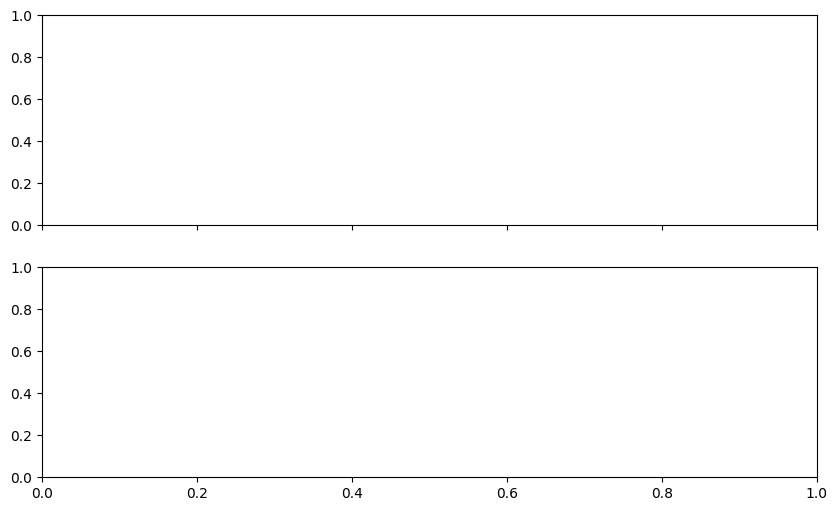

In [45]:
# --------------------
# Bode-style magnitude + phase
# --------------------

# Slice indices across H axes:
#   H[oru_idx, rx_ant_idx, tx_ant_idx, freq_bins, dmrs_symbols]
oru_idx = 0
rx_ant_idx = 0
tx_ant_idx = 0

#error

selection_title = 'random' if SELECTION_STRATEGY == 'random' else 'consecutive'


# Frequency-bin slice (index range, not physical Hz)
freq_start_bode = 0
freq_end_bode = None  # set to an int to zoom

eps = 1e-6

for label_idx, label in enumerate(LABELS):

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    for sample_i in range(N_PICKLES_PER_LABEL):

        # H has shape [n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
        H = H_all[label_idx, sample_i]

        # take phase and mag of only one Rx antenna
        H_line = H[oru_idx, rx_ant_idx, tx_ant_idx, :, :]  # (freq_bins)

        '''
        phase_line_dmrs0 = np.angle(H_line[:,0])
        phase_line_dmrs0 = np.unwrap(phase_line_dmrs0)
        mag_line_dmrs0 = np.abs(H_line[:,0])

        phase_line_dmrs1 = np.angle(H_line[:,1])
        phase_line_dmrs1 = np.unwrap(phase_line_dmrs1)
        mag_line_dmrs1 = np.abs(H_line[:,1])

        phase_line_dmrs2 = np.angle(H_line[:,2])
        phase_line_dmrs2 = np.unwrap(phase_line_dmrs2)
        mag_line_dmrs2 = np.abs(H_line[:,2])
        '''

        # average over all DMRS symbols
        H_line_dmrs_avg = np.mean(H_line, axis=-1, keepdims=False)

        phase_dmrs_avg = np.angle(H_line_dmrs_avg)
        mag_dmrs_avg = np.abs(H_line_dmrs_avg)

        phase_dmrs_avg = np.unwrap(phase_dmrs_avg)

        fs = 0
        fe = H_line.shape[0]

        if fe <= fs:
            raise ValueError(f"Invalid bode slice: fs={fs}, fe={fe}")

        f_bins = np.arange(fs, fe)

        '''
        mag_line_dmrs0_slice = mag_line_dmrs0[fs:fe]
        phase_line_dmrs0_slice = phase_line_dmrs0[fs:fe]

        mag_line_dmrs1_slice = mag_line_dmrs1[fs:fe]
        phase_line_dmrs1_slice = phase_line_dmrs1[fs:fe]

        mag_line_dmrs2_slice = mag_line_dmrs2[fs:fe]
        phase_line_dmrs2_slice = phase_line_dmrs2[fs:fe]
        '''

        mag_dmrs_avg_slice = mag_dmrs_avg[fs:fe]
        phase_dmrs_avg_slice = phase_dmrs_avg[fs:fe]

        mag_ylabel = 'Magnitude |H|'

        axes[0].plot(f_bins, mag_dmrs_avg_slice, linewidth=1.0)
        axes[1].plot(f_bins, phase_dmrs_avg_slice, linewidth=1.0)

        '''
        axes[0].plot(f_bins, mag_line_dmrs0_slice, linewidth=1.0)
        axes[1].plot(f_bins, phase_line_dmrs0_slice, linewidth=1.0)

        axes[0].plot(f_bins, mag_line_dmrs1_slice, linewidth=1.0)
        axes[1].plot(f_bins, phase_line_dmrs1_slice, linewidth=1.0)

        axes[0].plot(f_bins, mag_line_dmrs2_slice, linewidth=1.0)
        axes[1].plot(f_bins, phase_line_dmrs2_slice, linewidth=1.0)
        '''
    
    
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylabel(mag_ylabel)
    axes[0].set_title(
        f"Bode plot | {selection_title} raw CSI sample idx={sample_rec_arr[label_idx*N_PICKLES_PER_LABEL+sample_i][1]} | Label={label}\n"
        f"Magnitude and Phase are from oru={oru_idx}, rx={rx_ant_idx}, tx={tx_ant_idx}, dmrs_sym_idx=averaged_out"
    )

    #plt.legend(np.arange(N_PICKLES_PER_LABEL))

    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylabel('Phase (rad)')
    axes[1].set_xlabel('Subcarrier index (0..n_prbs*12-1)')

    #axes[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))

    plt.tight_layout()

    out_name = (
        f"bode_raw_{label}_{selection_title}_sample_idx={sample_rec_arr[label_idx*N_PICKLES_PER_LABEL+sample_i][1]}_dmrs_averaged.png"
    )
    #plt.savefig(out_name, dpi=300, bbox_inches='tight')
    plt.show()

    print('Rec pickle:', sample_rec_arr[label_idx*N_PICKLES_PER_LABEL+sample_i][2])
    #print('H_sel_local.shape:', H_sel_local.shape, '(freq_bins, dmrs_symbols)')
    print(f'Plotted frequency bins: {fs}..{fe-1}')


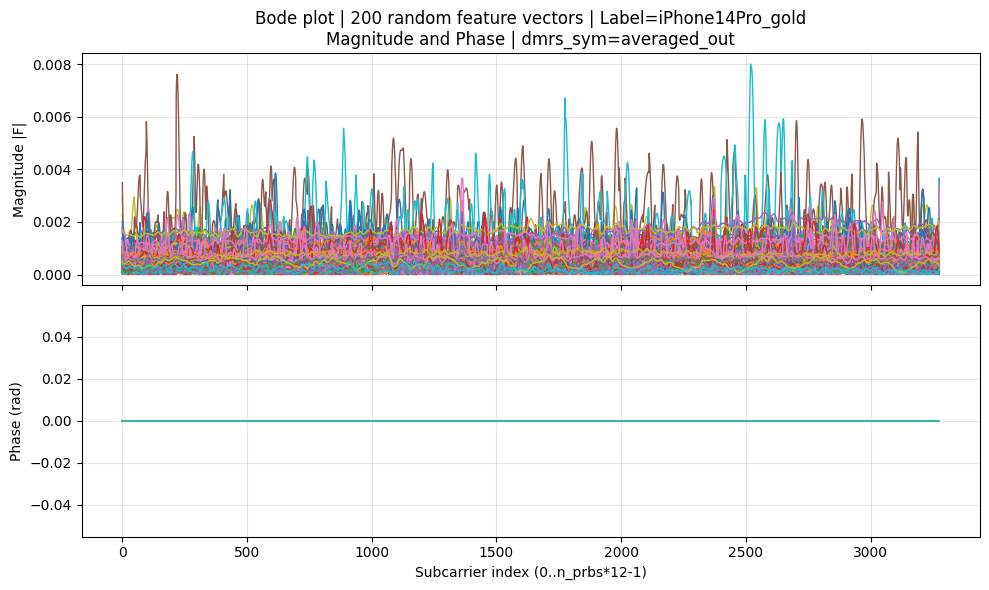

Plotted frequency bins: 0..3275


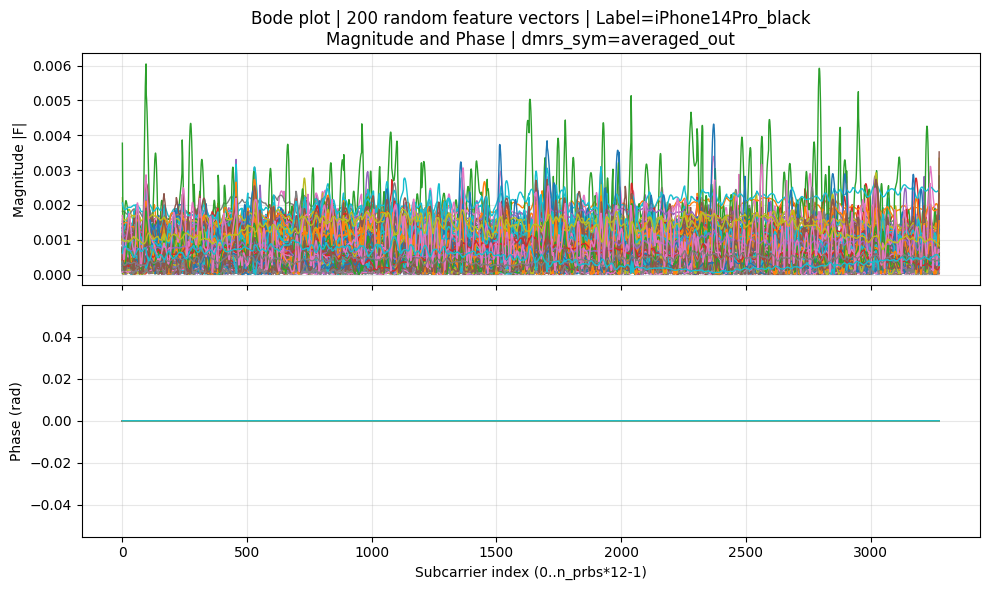

Plotted frequency bins: 0..3275


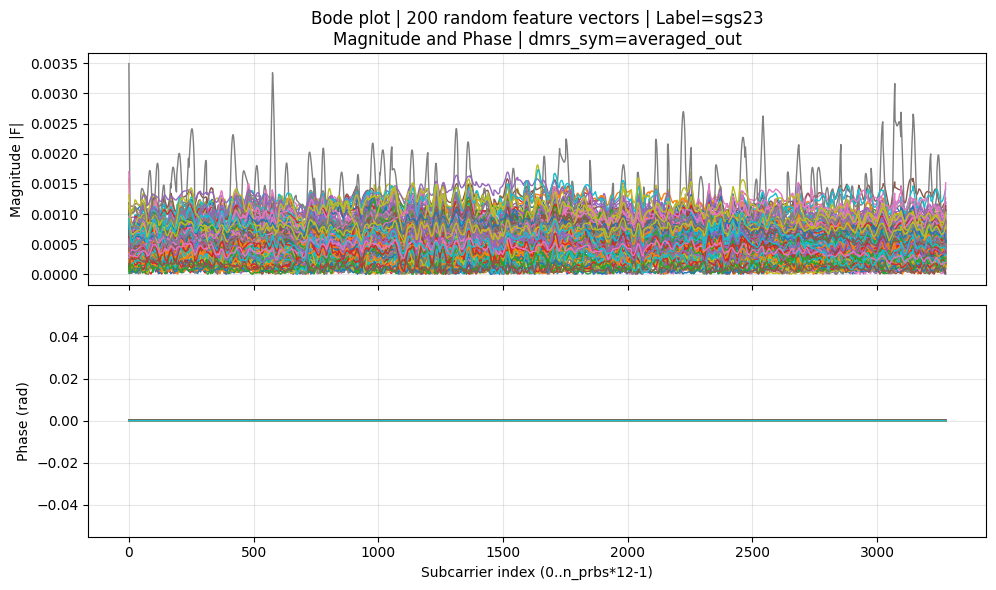

Plotted frequency bins: 0..3275


In [54]:
# --------------------
# Bode-style magnitude + phase for fingerprints
# --------------------

selection_title = 'random' if SELECTION_STRATEGY == 'random' else 'consecutive'


# Frequency-bin slice (index range, not physical Hz)
freq_start_bode = 0
freq_end_bode = None  # set to an int to zoom

eps = 1e-6

for label_idx, label in enumerate(LABELS):

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    for sample_i in range(N_PICKLES_PER_LABEL):

        #feature_vec = global_features[label_idx*N_PICKLES_PER_LABEL+sample_i]
        feature_vec = features_list[label_idx, sample_i]

        phase = np.angle(feature_vec)
        mag = np.abs(feature_vec)

        phase = np.unwrap(phase)

        fs = 0
        fe = feature_vec.shape[0]

        if fe <= fs:
            raise ValueError(f"Invalid bode slice: fs={fs}, fe={fe}")

        f_bins = np.arange(fs, fe)

        mag_slice = mag[fs:fe]
        phase_slice = phase[fs:fe]

        mag_ylabel = 'Magnitude |F|'

        axes[0].plot(f_bins, mag_slice, linewidth=1.0)
        axes[1].plot(f_bins, phase_slice, linewidth=1.0)
    
    
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylabel(mag_ylabel)
    axes[0].set_title(
        f"Bode plot | {N_PICKLES_PER_LABEL} {selection_title} feature vectors | Label={label}\n"
        f"Magnitude and Phase | dmrs_sym=averaged_out"
    )

    #plt.legend(np.arange(N_PICKLES_PER_LABEL))

    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylabel('Phase (rad)')
    axes[1].set_xlabel('Subcarrier index (0..n_prbs*12-1)')

    #axes[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))

    plt.tight_layout()

    out_name = (
        f"bode_features_{label}_{N_PICKLES_PER_LABEL}_{selection_title}_samples_dmrs_averaged.png"
    )
    #plt.savefig(out_name, dpi=300, bbox_inches='tight')
    plt.show()

    #print('Rec pickle:', sample_rec_arr[label_idx*N_PICKLES_PER_LABEL+sample_i][2])
    #print('H_sel_local.shape:', H_sel_local.shape, '(freq_bins, dmrs_symbols)')
    print(f'Plotted frequency bins: {fs}..{fe-1}')


In [8]:
# LOAD PICKLE FILES

# Check whether to assert reshape correctness
reshape_check = True

#samples = []
sample_paths = []
sample_rec_arr = []
sample_dicts = np.zeros((len(LABELS), N_PICKLES_PER_LABEL), dtype=object)
H_list = []

for i, label in enumerate(LABELS):

    working_dict = sample_dicts[i]

    all_paths = list_pickles_for_label(DATASET_BASE, SPLIT, label, debug=True)
    if not all_paths:
        raise FileNotFoundError(f"No pickle files found for label='{label}' under {DATASET_BASE}/{SPLIT}")
    chosen, chosen_indices = select_subset_with_indices(all_paths, N_PICKLES_PER_LABEL, SELECTION_STRATEGY, my_rng, m=START_OFFSET)
    print(f"Label={label}: found {len(all_paths)} pickles, selected {len(chosen)}")
    
    i=0
    for p, pre_rng_idx in zip(chosen, chosen_indices):
        with open(p, 'rb') as f:
            x = pickle.load(f)
    
        # Match dataset_preparation.py behavior
        h_arr = np.array(x['ch_est'])
        H = np.squeeze(h_arr, axis=1) # [n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
        H_list.append(H)
    
        # Useful debug info
        sample_rec_arr.append([label, pre_rng_idx, p])
        base = os.path.basename(p)
        sample_paths.append(base)

        rec = {
            'pickle_path': p,
            'label': label,
            'pre_rng_index_within_label': pre_rng_idx,
            'raw csi': h_arr,
            'H': H
        }
        working_dict[i] = rec
        i+=1


H_list_stacked = np.stack(H_list, axis=0) # [len(LABELS)*N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
assert H_list_stacked.shape[0] == len(LABELS) * N_PICKLES_PER_LABEL

H_all = np.reshape(H_list_stacked, [len(LABELS), N_PICKLES_PER_LABEL, *H_list_stacked.shape[1:]])
# H_all has dimension: [len(LABELS), N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]

# check whether reshape is done correctly
if reshape_check:
    flat_idx = 0
    for i in range(len(LABELS)):
        for j in range(N_PICKLES_PER_LABEL):
            # uses np.all under the hood to make sure that all elements are compared
            assert np.allclose(H_all[i, j], sample_dicts[i, j]['H'], atol=1e-6), f"Mismatch 1 at Label {i}, Sample {j}"
            assert np.allclose(H_all[i, j], H_list_stacked[flat_idx], atol=1e-6), f"Mismatch 2 at Label {i}, Sample {j}"
            flat_idx += 1

    print("Reshape assertion passed successfully!")

print('\nTotal loaded samples:', len(sample_rec_arr))
if len(sample_rec_arr) == 0:
    raise RuntimeError('No samples loaded')

print('Example labels:', sorted(set(s[0] for s in sample_rec_arr)))
#print('Ensure randomness:', sorted(set(s[1] for s in sample_rec_arr)))
#print('\nH_all shape:', H_all.shape)


Pattern:  /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/*.pickle
/scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.542_53579.pickle
/scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.552_53579.pickle
/scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.557_53579.pickle
/scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.572_53579.pickle
/scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.577_53579.pickle
/scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.582_53579.pickle
/scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.592_53579.pickle
/scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.597_53579.pickle
/scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.602_53579.pickle
/scratch/bsc26f18/datasets/de

In [ ]:
# RF-FINGERPRINT FEATURE EXTRACTION

reshape_check = True
cupy_check = True

# Numpy flattens arrays in row-major order

# H_all has dimension: [len(LABELS), N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
H_ = np.transpose(H_all, [0,1,4,5,6,2,3])
H_ = np.reshape(H_, [len(LABELS), N_PICKLES_PER_LABEL, n_tx_ant*n_prbs*12*n_dmrs_symbols, -1])
# H_ is [len(LABELS), N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12 * n_dmrs_symbols, n_orus * n_rx_ant_per_oru]

# check whether reshape is done correctly
if reshape_check:
    L, P, O, R, T, Pr, D_sym = H_all.shape
    i, j, o, r, t, p, d = np.indices(H_all.shape)

    flat_dim_2_idx = (t * (Pr * D_sym)) + (p * D_sym) + d
    flat_dim_3_idx = (o * R) + r

    H_mapped = H_[i, j, flat_dim_2_idx, flat_dim_3_idx]

    assert np.allclose(H_all, H_mapped, atol=1e-6), "Mismatch found in manual vectorized mapping!"
    
    print("Vectorized manual index mapping assertion passed successfully!")

    print("Reshape assertion to H_ passed successfully!")

H_ = H_ / np.linalg.norm(H_, axis=-1, keepdims=True)

U, S, Vh = np.linalg.svd(H_, full_matrices=False, compute_uv=True, hermitian=False)
principal_singular_vector = U[:,:,:,0].astype(np.complex64)

if cupy_check:
    # dataset_preparation.py uses cupy:
    U_cp, S_cp, Vh_cp = cp.linalg.svd(cp.array(H_), full_matrices=False, compute_uv=True)
    principal_singular_vector_cp = np.take(U_cp.get(), indices=0, axis=-1)

    assert np.allclose(principal_singular_vector, principal_singular_vector_cp, atol=1e-6), "Mismatch found in principal singular vector!"

    print("SVD assertion passed successfully!")

# print('principal_singular_vector shape:', principal_singular_vector.shape)
# print('n_tx_ant * n_prbs * 12 * n_dmrs_symbols:', n_tx_ant * n_prbs * 12 * n_dmrs_symbols)

# NEED TO CHECK FOR CORRECTNESS OF RESHAPING

# principal_singular_vector has dims [len(LABELS), N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12 * n_dmrs_symbols]
features = np.reshape(principal_singular_vector, [
    len(LABELS), N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12, n_dmrs_symbols])
# features has dims [len(LABELS), N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12, n_dmrs_symbols]

'''
# features: [L, N, F, S], complex
eps = 1e-12
ref = np.sum(features, axis=2, keepdims=True)            # [L, N, 1, S]
phase = np.exp(-1j * np.angle(ref + eps))                # [L, N, 1, S]
features_aligned = features * phase                      # [L, N, F, S]
'''

# FLATTEN FEATURES TO USE AVERAGE OVER DMRS SYMBOLS BECAUSE THE CHANGE IS ALMOST NON-EXISTENT
features_flat = np.mean(features, axis=-1, keepdims=False)
# features_flat has dims [len(LABELS), N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12]

# NEED TO CHECK FOR CORRECTNESS OF RESHAPING
assert features_flat.shape == (len(LABELS), N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12), "features_flat shape mismatch (numpy vs. cupy)"

global_features = np.reshape(features_flat, [-1, n_tx_ant * n_prbs * 12])
# global_features has dims [len(LABELS) * N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12]
assert global_features.shape == (len(LABELS) * N_PICKLES_PER_LABEL, n_tx_ant * n_prbs * 12), "global_features shape mismatch"

if reshape_check:
    flat_idx = 0
    for i in range(len(LABELS)):
        for j in range(N_PICKLES_PER_LABEL):
            # uses np.all under the hood to make sure that all elements are compared
            assert np.allclose(features_flat[i, j], global_features[flat_idx], atol=1e-6), f"Mismatch 1 at Label {i}, Sample {j}"
            flat_idx += 1

    print("Reshape assertion to global_features passed successfully!")


# create local device IDs for identification later in the plot
device_ids = np.arange(len(LABELS))
global_labels = np.repeat(device_ids, N_PICKLES_PER_LABEL)
# global_labels has dims [len(LABELS) * N_PICKLES_PER_LABEL]
# because neither PCA nor Sammon's mapping shuffles or reorders the data we can use the global_labels to identify the data

Vectorized manual index mapping assertion passed successfully!
Reshape assertion to H_ passed successfully!
Reshape assertion to global_features passed successfully!


In [47]:
# COMPUTE DIFFERENT DISTANCE METRICS BETWEEN SAMPLES

def compute_distance_matrices(X=global_features, L2=True, Cosine=True, Chordal=False, Bures=False):
    """Compute several pairwise distance matrices from feature matrix X [N, F]."""

    #N = X.shape[0]
    distances = {}

    # --- L2 (Euclidean) distance ---
    if L2:
        sq_norms = np.sum(np.abs(X)**2, axis=1, keepdims=True)
        D_l2 = sq_norms + sq_norms.T - 2 * np.real(X @ X.conj().T)
        D_l2 = np.sqrt(np.maximum(D_l2, 0.0))
        distances['L2'] = D_l2
        print(f"L2 distance shape: {D_l2.shape}")

    G = X @ X.conj().T

    # --- Cosine distance ---
    if Cosine:
        norms = np.sqrt(np.sum(np.abs(X)**2, axis=1, keepdims=True))
        cos_sim = np.abs(G) / (norms @ norms.T)
        D_cos = 1.0 - cos_sim
        D_cos = np.maximum(D_cos, 0.0)
        distances['Cosine'] = D_cos


    abs_cos_sim = np.abs(G) / (norms @ norms.T)

    # --- Chordal distance ---
    # For unit-norm vectors on the complex sphere, chordal distance is:
    #   d_chordal(x, y) = sqrt(1 - |<x,y>|^2 / (||x||^2 ||y||^2))
    if Chordal:
        D_chordal = np.sqrt(np.maximum(1.0 - abs_cos_sim**2, 0.0))
        distances['Chordal'] = D_chordal

    # --- Bures-Wasserstein distance ---
    # For unit-norm vectors on the complex sphere, Bures-Wasserstein distance is:
    #   d_bures(x, y) = sqrt(1 - |<x,y>| / (||x|| ||y||))
    if Bures:
        D_bures = np.sqrt(np.maximum(1.0 - abs_cos_sim, 0.0))
        distances['Bures'] = D_bures

    return distances

In [48]:
# EXTRACT INTRA- AND INTER-CLASS DISTANCES

def extract_class_distances(D, global_labels, labels):
    """
    Given a [N, N] pairwise distance matrix, extract:
      - intra_distances: dict {label: 1D array of within-class distances}
      - inter_distances: dict {(label_i, label_j): 1D array of between-class distances}
    Only upper-triangle entries are used (avoids double-counting and self-distances).
    """
    intra_distances = {}
    inter_distances = {}

    for i, li in enumerate(labels):
        mask_i = (global_labels == i)
        
        # Intra-class: upper triangle of the D[mask_i][:, mask_i] block
        D_block = D[np.ix_(mask_i, mask_i)]
        triu_idx = np.triu_indices(D_block.shape[0], k=1)
        intra_distances[li] = np.real(D_block[triu_idx])

        for j, lj in enumerate(labels):
            if j <= i:
                continue
            mask_j = (global_labels == j)
            # Inter-class: full rectangular block (no symmetry to exploit)
            inter_distances[(li, lj)] = np.real(D[np.ix_(mask_i, mask_j)].ravel())

    return intra_distances, inter_distances

L2 distance shape: (6000, 6000)


/tmp/ipykernel_2958640/2634394340.py:51: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


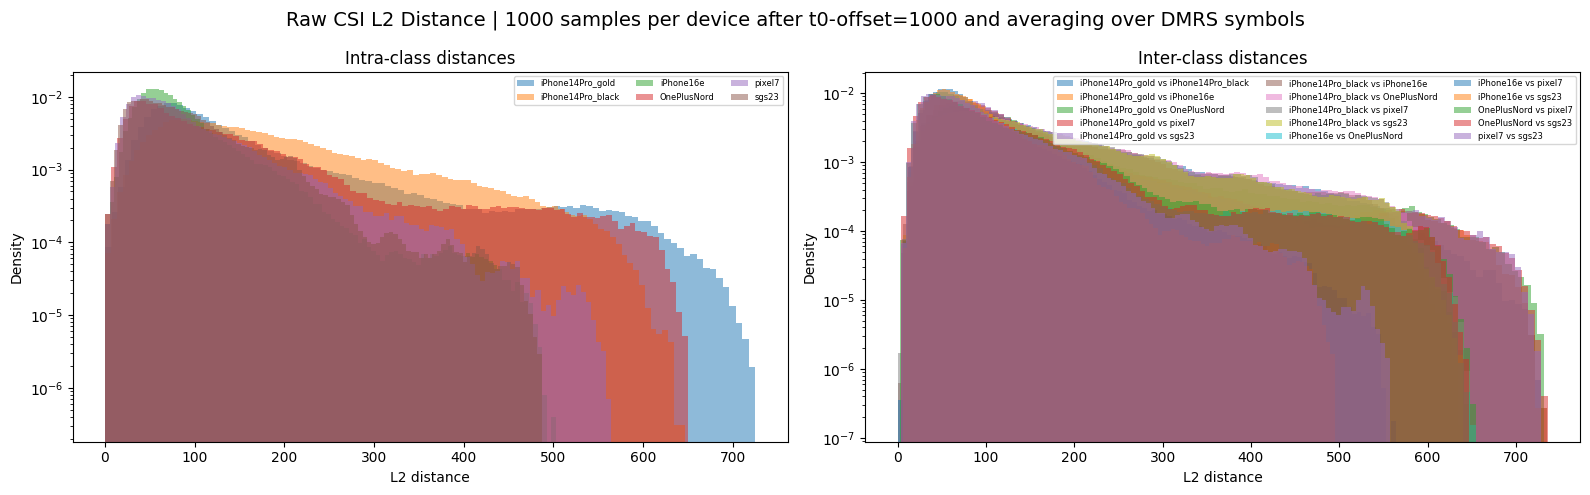

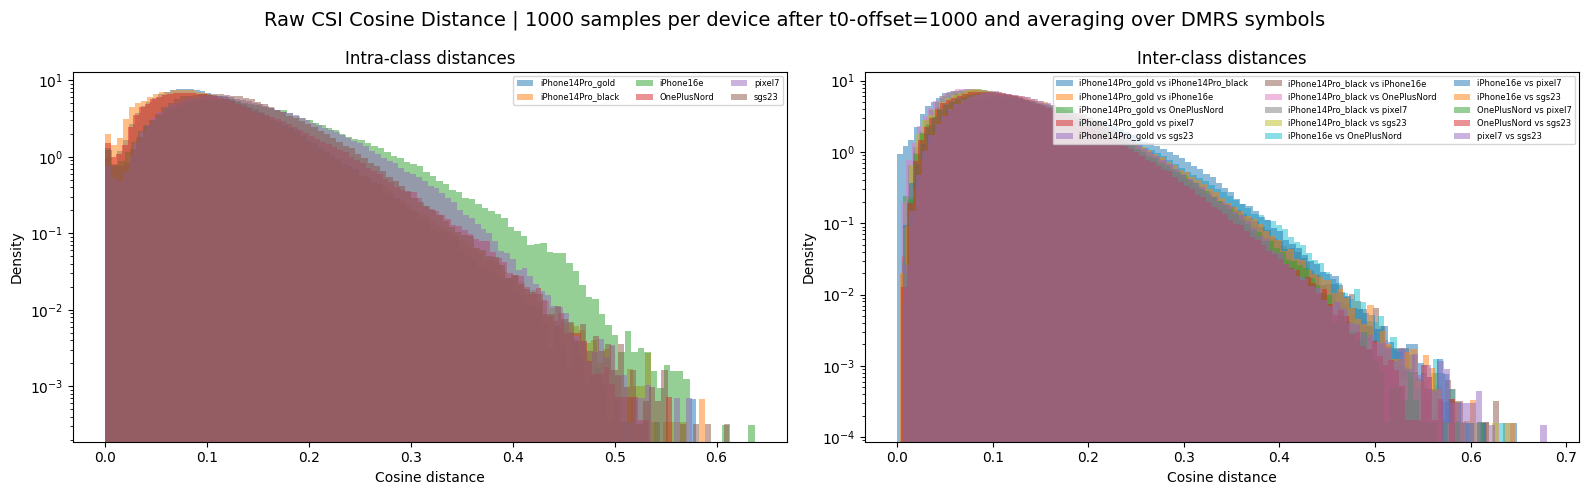

In [30]:
# PLOT RAW CSI HISTOGRAMS

n_bins = 100  # adjust as needed

# H_list_stacked has dimension [len(LABELS)*N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
n_orus_idx = 0
n_rx_ant_per_oru_idx = 0
n_tx_ant_idx = 0

#average over n_dmrs_symbols
H_list_stacked_slice_flat = np.mean(H_list_stacked[:, n_orus_idx, n_rx_ant_per_oru_idx, n_tx_ant_idx, :, :], axis=-1, keepdims=False)

# H_list_stacked_slice_flat has dimension [len(LABELS)*N_PICKLES_PER_LABEL, n_prbs*12]
all_distances = compute_distance_matrices(np.abs(H_list_stacked_slice_flat))

for metric_name, D_metric in all_distances.items():
    intra, inter = extract_class_distances(D_metric, global_labels, LABELS) # global_labels also works with H_list_stacked_slice_flat
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plt.title(f"Raw CSI distance histograms of {', '.join(LABELS)} with {N_PICKLES_PER_LABEL} samples each")
    fig.suptitle(f'Raw CSI {metric_name} Distance | {N_PICKLES_PER_LABEL} samples per device after t0-offset={START_OFFSET} and averaging over DMRS symbols', fontsize=14)

    # --- Intra-class histograms (overlaid) ---
    ax = axes[0]
    for label_name, dists in intra.items():
        ax.hist(dists, bins=n_bins, alpha=0.5, density=True, label=label_name)
    ax.set_xlabel(f'{metric_name} distance')
    ax.set_ylabel('Density')
    ax.set_title('Intra-class distances')
    ax.legend(fontsize=6, ncol=3)
    ax.set_yscale('log')

    # --- Inter-class histograms (overlaid) ---
    ax = axes[1]
    for (li, lj), dists in inter.items():

        if metric_name == 'Bures' or metric_name == 'Chordal':
            bin_edges = np.linspace(0, 1, n_bins + 1)
        else:
            bin_edges = n_bins
        ax.hist(dists, bins=bin_edges, alpha=0.5, density=True, label=f'{li} vs {lj}')
        
    ax.set_xlabel(f'{metric_name} distance')
    ax.set_ylabel('Density')
    ax.set_title('Inter-class distances')
    ax.legend(fontsize=6, ncol=3)
    ax.set_yscale('log')

    #plt.savefig(f"{metric_name}_raw_csi_distance_histograms_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_samples.png", dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

L2 distance shape: (6000, 6000)


/tmp/ipykernel_2958640/2447269678.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"{metric_name}_feature_vector_distance_histograms_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_samples.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_2958640/2447269678.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


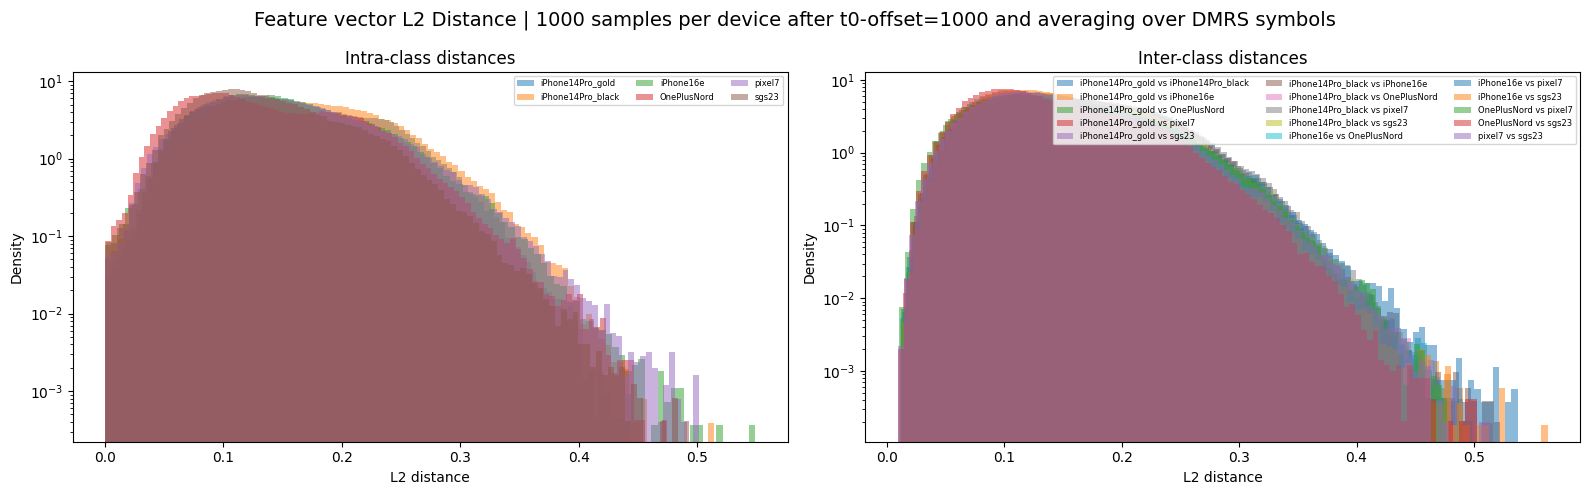

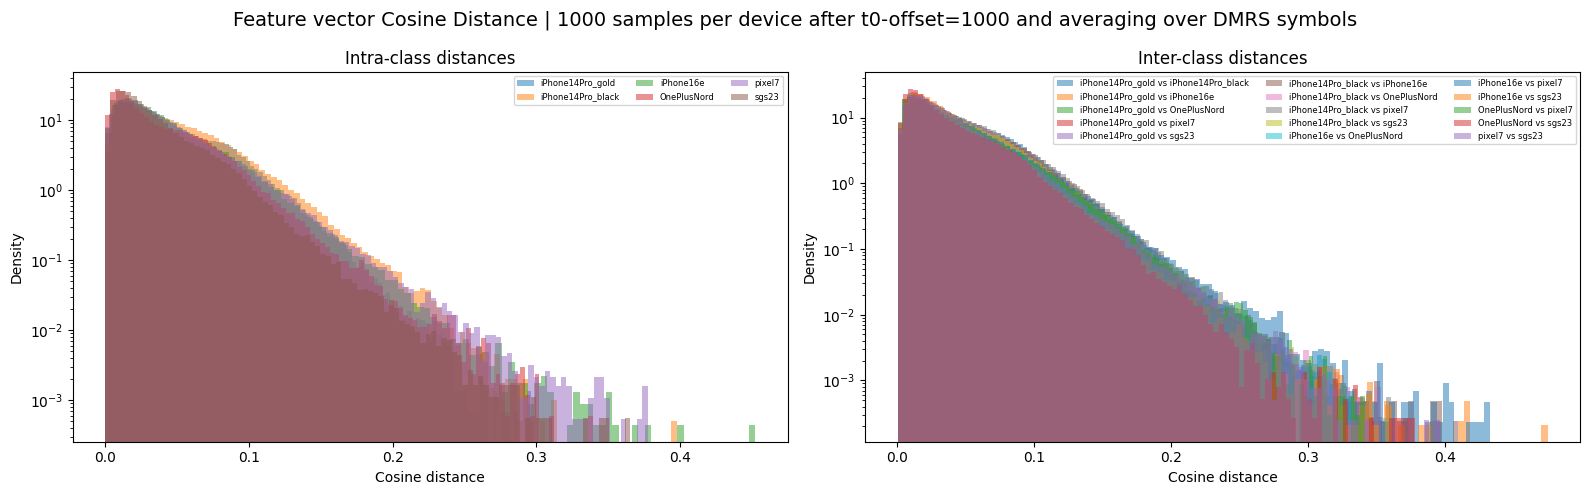

In [31]:
# PLOT RF-FINGERPRINT HISTOGRAMS

n_bins = 100  # adjust as needed

all_distances = compute_distance_matrices(np.abs(global_features))

for metric_name, D_metric in all_distances.items():
    intra, inter = extract_class_distances(D_metric, global_labels, LABELS)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plt.title(f"Feature vector distance histograms of {', '.join(LABELS)} with {N_PICKLES_PER_LABEL} samples each")
    fig.suptitle(f'Feature vector {metric_name} Distance | {N_PICKLES_PER_LABEL} samples per device after t0-offset={START_OFFSET} and averaging over DMRS symbols', fontsize=14)

    # --- Intra-class histograms (overlaid) ---
    ax = axes[0]
    for label_name, dists in intra.items():
        ax.hist(dists, bins=n_bins, alpha=0.5, density=True, label=label_name)
    ax.set_xlabel(f'{metric_name} distance')
    ax.set_ylabel('Density')
    ax.set_title('Intra-class distances')
    ax.legend(fontsize=6, ncol=3)
    ax.set_yscale('log')

    # --- Inter-class histograms (overlaid) ---
    ax = axes[1]
    for (li, lj), dists in inter.items():
        if metric_name == 'Bures' or metric_name == 'Chordal':
            bin_edges = np.linspace(0, 1, n_bins + 1)
        else:
            bin_edges = n_bins
        ax.hist(dists, bins=bin_edges, alpha=0.5, density=True, label=f'{li} vs {lj}')
    ax.set_xlabel(f'{metric_name} distance')
    ax.set_ylabel('Density')
    ax.set_title('Inter-class distances')
    ax.legend(fontsize=6, ncol=3)
    ax.set_yscale('log')
    plt.savefig(f"{metric_name}_feature_vector_distance_histograms_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_samples.png", dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

In [84]:
# PREPARE RAW CSI SAMPLES FOR SAMMON'S MAPPING

# COMPUTE PAIRWISE L2 DISTANCE MATRIX BETWEEN SAMPLES (EACH SAMPLE CORRESPONDS TO ONE FEATURE VECTOR)

# H_list_stacked_slice_flat has dims [len(LABELS)*N_PICKLES_PER_LABEL, n_prbs*12] and is averaged over n_dmrs_symbols
D_raw = compute_distance_matrices(global_features)
D_raw_l2 = D_raw['L2']
D_raw_cosine = D_raw['Cosine']
#D_raw_chordal = D_raw['Chordal']
#D_raw_bures = D_raw['Bures']

# D includes all distances, some of which are featured multiple times

L2 distance shape: (4000, 4000)


In [ ]:
# PREPARE FEATURES FOR SAMMON'S MAPPING

# COMPUTE PAIRWISE COSINE DISTANCE MATRIX BETWEEN SAMPLES (EACH SAMPLE CORRESPONDS TO ONE FEATURE VECTOR)

X = global_features

nominator = X @ X.conj().T
norm2_X = np.sqrt(np.sum(np.abs(X)**2, axis=1, keepdims=True))

D = 1 - nominator / (norm2_X @ norm2_X.conj().T)

D = np.maximum(D, 0.0) # Deal with numerical errors
# DO WE HAVE TO NORMALIZE D???
print("Cos_Distance shape: ", D.shape)


'''
# COMPUTE PAIRWISE EUCLIDEAN DISTANCE MATRIX BETWEEN SAMPLES (EACH SAMPLE CORRESPONDS TO ONE FEATURE VECTOR)

# Do it the same way as Prof. Studer in CC MATLAB code to make it more efficient than np.linalg.norm
# ||xi - xj||^2 = ||xi||^2 + ||xj||^2 - 2*Re(xi*conj(xj))

X = global_features

sum_features = np.sum(np.abs(X)**2, axis=1, keepdims=True)
cross_term = 2*np.real(X @ X.conj().T) # [len(LABELS)*N_PICKLES_PER_LABEL, len(LABELS)*N_PICKLES_PER_LABEL]

d_cov = sum_features + sum_features.T - cross_term # [len(LABELS)*N_PICKLES_PER_LABEL, len(LABELS)*N_PICKLES_PER_LABEL], describes the relationship between all samples
d_cov = np.sqrt(np.maximum(d_cov, 0.0)) # Deal with numerical errors
d_cov = d_cov/np.std(d_cov)
#np.fill_diagonal(d_cov, 0.0) # Force the diagonal to be 0.0 to avoid self-distances for MATLAB script to work

# D has dims [len(LABELS)*N_PICKLES_PER_LABEL, len(LABELS)*N_PICKLES_PER_LABEL]
D = d_cov
print("D shape: ", D.shape)
'''

In [80]:
# TRANSFER D TO MATLAB FOR SAMMON'S MAPPING

scratch_dir = Path('/scratch/bsc26f18/sammon_scratch')
scratch_dir.mkdir(parents=True, exist_ok=True)

no_dims = 2

d_cov = np.asarray(D_raw_l2, dtype=np.float64)  # MATLAB will read this as double
out_mat = scratch_dir / f"d_cov.mat"
sc.io.savemat(out_mat, {"d_cov": d_cov, "no_dims": int(no_dims)})
print("Wrote:", out_mat)

Wrote: /scratch/bsc26f18/sammon_scratch/d_cov.mat


In [77]:
# READ MATLAB MAPPEDX FILES

mat_file = scratch_dir / f"mappedX.mat"
if not mat_file.exists():
    raise FileNotFoundError(f"Mat file {mat_file} does not exist")
mappedX = sc.io.loadmat(mat_file)['mappedX']

# sammon_results has shape (2, len(LABELS)*N_PICKLES_PER_LABEL)
sammon_results = mappedX.T

S1 = sammon_results[0,:]
S2 = sammon_results[1,:]

print(f"mat_file_path: {mat_file}")
print(f"mappedX shape: {mappedX.shape}")
print(f"sammon_results shape: {sammon_results.shape}")

mat_file_path: /scratch/bsc26f18/sammon_scratch/mappedX.mat
mappedX shape: (12000, 2)
sammon_results shape: (2, 12000)


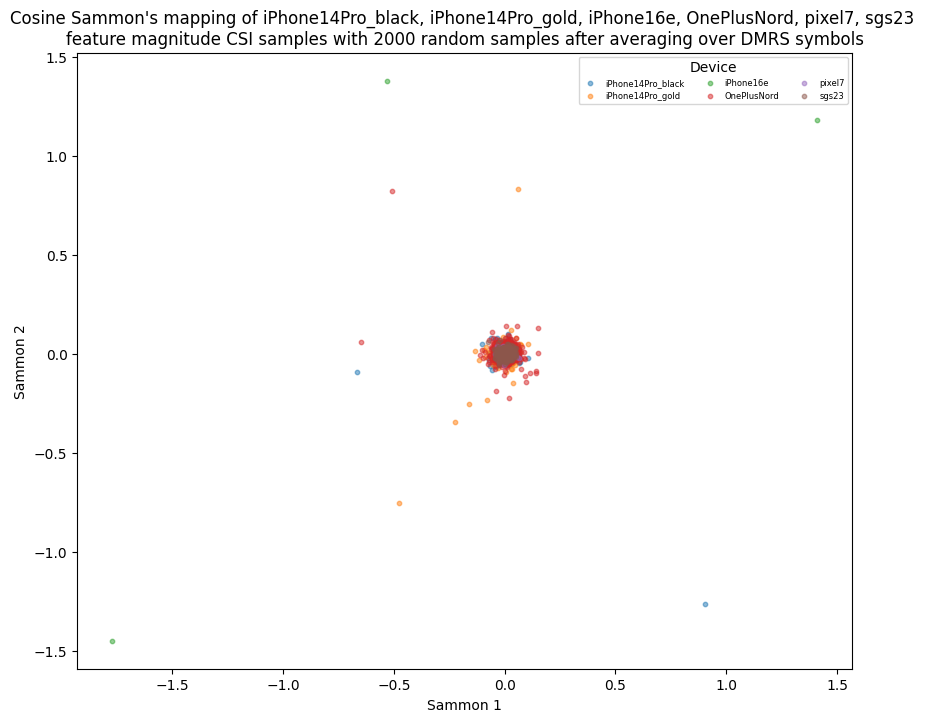

In [78]:
# PLOT SAMMON'S MAPPING RESULTS

plt.figure(figsize=(10, 8))

for label in device_ids:
    # Create a boolean mask for where the global_labels match the current device
    label_mask = (global_labels == label)

    # Scatter plot ONLY the points where the mask is True
    plt.scatter(
        S1[label_mask], 
        S2[label_mask], 
        label=LABELS[label], 
        alpha=0.5, 
        s=10  # Smaller dot size helps when plotting thousands of overlapping points
    )

plt.xlabel('Sammon 1')
plt.ylabel('Sammon 2')
plt.legend(title='Device', fontsize=6, ncol=3)
plt.title(f"Cosine Sammon's mapping of {', '.join(LABELS)} \n"
          f"feature magnitude CSI samples with {N_PICKLES_PER_LABEL} {SELECTION_STRATEGY} samples"
          f" after averaging over DMRS symbols")

#plt.savefig(f"Sammon_mapping_Cosine_features_csi_magnitude_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_samples.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
def compute_sammons_distance_matrix(S1, S2):
    # Computes the L2 distance matrix inside Sammon's mapping

    X = np.stack((S1,S2), axis=1)
    # X has dimension N_CONSECTUIVE_RANDOM_BATCHES x 2
    assert (X.shape == (len(LABELS)*N_PICKLES_PER_LABEL, 2)), f"X shape mismatch. Actual X shape: {X.shape}"
    
    sq_norms = np.sum(np.abs(X)**2, axis=1, keepdims=True)
    D_l2 = sq_norms + sq_norms.T - 2 * np.real(X @ X.conj().T)
    D_l2 = np.sqrt(np.maximum(D_l2, 0.0))

    print(f"L2 distance shape: {D_l2.shape}")

    return D_l2

In [ ]:
# COMPUTE K NEAREST NEIGHBORS

def get_knn(D, n, k):
    
    distances = D[n]
    # k+1 because n itself is included with distance 0
    idx = np.argpartition(distances, k + 1)[:k + 1]
    # argpartition does NOT sort the k elements, so we can continue to use global_labels
    # it returns the indices inside the D[n]-vector
    
    # Remove the point 'n' itself from the list of neighbors
    knn_indices = idx[idx != n][:k]
    
    return knn_indices

In [ ]:
# MAJORITY VOTING K-NN DETECTION

D = compute_sammons_distance_matrix(S1,S2)

k = int(0.05*N_PICKLES_PER_LABEL)
assert (k!=0), "k is too small"

detected_labels = np.zeros(global_labels.shape, dtype=int)

for n in range(global_features.shape[0]):
    knn_indices = get_knn(D,n,k)
    knn = D[n][knn_indices]
    knn_labels = global_labels[knn_indices]
    
    #bicount counts the occurences of each integer inside knn_labels (i.e. the label index), and argmax chooses the maximum of it
    majority_label_idx = np.bincount(knn_labels).argmax()
    detected_labels[n] = majority_label_idx
    #majority_label = LABELS[majority_label_idx]

In [ ]:
# COMPUTE LABEL ERROR RATE (LER)

# global LER ("weighted average" over labels)
LER = np.sum((global_labels != detected_labels))/global_features.shape[0]
print(f"SM global LER: {LER}")
print(f"")

# label-wise LER
LER_label = []
for l, li in enumerate(LABELS):
    print(f"UE: {li}")
    current_label_mask = (global_labels == l)
    N_l = np.sum(current_label_mask)
    current_LER = np.sum(detected_labels[current_label_mask]!=l)/N_l
    print(f"LER: {current_LER}")
    print(f"")
    LER_label.append(current_LER)

In [ ]:
# COMPUTE PCA SCORES FOR EACH LABEL
# THERE ARE DIFFERENT WAYS TO MAP Z_PCA ONTO A 2D PLANE, AS IT IS A COMPLEX MATRIX

Z_pca = dim_red_pca(global_features)
# Z_pca has dims [2, len(LABELS) * N_PICKLES_PER_LABEL]

print(f"Z_pca shape: {Z_pca.shape}")

Z1 = Z_pca[0,:]
Z2 = Z_pca[1,:]

In [ ]:
phase_Z1 = np.angle(Z1)
phase_Z2 = np.angle(Z2)

plt.figure(figsize=(10, 8))

print(f"Device ids: {device_ids}")

# Loop through each unique device name in your LABELS list
for label in device_ids:
    # Create a boolean mask for where the global_labels match the current device
    label_mask = (global_labels == label)

    
    # Scatter plot ONLY the points where the mask is True
    plt.scatter(
        phase_Z1[label_mask], 
        phase_Z2[label_mask], 
        label=LABELS[label], 
        alpha=0.5, 
        s=10  # Smaller dot size helps when plotting thousands of overlapping points
    )

plt.xlabel('Phase(Z1)')
plt.ylabel('Phase(Z2)')
plt.legend(title='Device', markerscale=3) # Makes the legend dots larger and easier to see
plt.title(f"Phase of {', '.join(LABELS)} PCA scores with {N_PICKLES_PER_LABEL} samples each")
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(f"PCA_Phase_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_samples.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
mag_Z1 = np.abs(Z1)
mag_Z2 = np.abs(Z2)

plt.figure(figsize=(10, 8))

print(f"Device ids: {device_ids}")

# Loop through each unique device name in your LABELS list
for label in device_ids:
    # Create a boolean mask for where the global_labels match the current device
    label_mask = (global_labels == label)

    
    # Scatter plot ONLY the points where the mask is True
    plt.scatter(
        mag_Z1[label_mask], 
        mag_Z2[label_mask], 
        label=LABELS[label], 
        alpha=0.5, 
        s=10  # Smaller dot size helps when plotting thousands of overlapping points
    )

plt.xlabel('|Z1|')
plt.ylabel('|Z2|')
plt.legend(title='Device', markerscale=3) # Makes the legend dots larger and easier to see
plt.title(f"Absolute values of {', '.join(LABELS)} PCA scores with {N_PICKLES_PER_LABEL} samples each")
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(f"PCA_Abs_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_samples.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
re_Z1 = np.real(Z1)
im_Z1 = np.imag(Z1)

plt.figure(figsize=(10, 8))

print(f"Device ids: {device_ids}")

# Loop through each unique device name in your LABELS list
for label in device_ids:
    # Create a boolean mask for where the global_labels match the current device
    label_mask = (global_labels == label)

    
    # Scatter plot ONLY the points where the mask is True
    plt.scatter(
        re_Z1[label_mask], 
        im_Z1[label_mask], 
        label=LABELS[label], 
        alpha=0.5, 
        s=10  # Smaller dot size helps when plotting thousands of overlapping points
    )

plt.xlabel('Re(Z1)')
plt.ylabel('Im(Z1)')
plt.legend(title='Device', markerscale=3) # Makes the legend dots larger and easier to see
plt.title(f"Real and imaginary parts of first PCA components of {', '.join(LABELS)} with {N_PICKLES_PER_LABEL} samples each")
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(f"PCA_Im_vs_Re_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_samples.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# THIS CELL PLOTS RE(Z2) VS RE(Z1)

re_Z1 = np.real(Z1)
re_Z2 = np.real(Z2)

plt.figure(figsize=(10, 8))

print(f"Device ids: {device_ids}")

# Loop through each unique device name in your LABELS list
for label in device_ids:
    # Create a boolean mask for where the global_labels match the current device
    label_mask = (global_labels == label)

    
    # Scatter plot ONLY the points where the mask is True
    plt.scatter(
        re_Z1[label_mask], 
        re_Z2[label_mask], 
        label=LABELS[label], 
        alpha=0.5, 
        s=10  # Smaller dot size helps when plotting thousands of overlapping points
    )

plt.xlabel('Re(Z1)')
plt.ylabel('Re(Z2)')
plt.legend(title='Device', markerscale=3) # Makes the legend dots larger and easier to see
plt.title(f"Real parts of {', '.join(LABELS)} PCA scores with {N_PICKLES_PER_LABEL} samples each")
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(f"PCA_Im_vs_Re_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_samples.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# THIS CELL PLOTS Z2 VS Z1, IF PCA OUTPUT IS REAL FROM A REAL INPUT

plt.figure(figsize=(10, 8))

#print(f"Device ids: {device_ids}")

# Loop through each unique device name in your LABELS list
for label in device_ids:
    # Create a boolean mask for where the global_labels match the current device
    label_mask = (global_labels == label)

    
    # Scatter plot ONLY the points where the mask is True
    plt.scatter(
        Z1[label_mask], 
        Z2[label_mask], 
        label=LABELS[label], 
        alpha=0.5, 
        s=10  # Smaller dot size helps when plotting thousands of overlapping points
    )

plt.xlabel('Z1')
plt.ylabel('Z2')
plt.legend(title='Device', markerscale=3) # Makes the legend dots larger and easier to see
plt.title(f"{', '.join(LABELS)} PCA scores with {N_PICKLES_PER_LABEL} samples each")
plt.grid(True, linestyle='--', alpha=0.5)

#plt.savefig(f"PCA_Im_vs_Re_{len(LABELS)}_devices_{N_PICKLES_PER_LABEL}_samples.png", dpi=300, bbox_inches='tight')
plt.show()